# Agricultural Climate & Market Analysis - Graph Generation
## Comprehensive Visualization Suite for RIFT Project

This notebook generates professional-quality graphs showing:
- Climate factors (temperature, rainfall)
- Yield analysis
- Market pricing
- Demand trends
- Risk indicators

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

print("✓ Libraries imported: numpy, pandas, matplotlib, seaborn")
print("✓ Ready for graph generation")

✓ Libraries imported: numpy, pandas, matplotlib, seaborn
✓ Ready for graph generation


## 1. Generate Agricultural Dataset (1050 rows)

In [2]:
np.random.seed(42)
print("Generating 1050 agricultural data points...")

start_date = datetime(2021, 1, 1)
dates = [start_date + timedelta(days=x) for x in range(210)]
crops = ['Wheat', 'Corn', 'Soybeans', 'Rice', 'Barley']

data = []
for date in dates:
    for crop in crops:
        day_of_year = date.timetuple().tm_yday
        seasonal_temp = 20 + 15 * np.sin(2 * np.pi * day_of_year / 365)
        seasonal_rain = 50 + 30 * np.sin(2 * np.pi * (day_of_year - 90) / 365)
        
        temperature = seasonal_temp + np.random.normal(0, 5)
        rainfall = max(0, seasonal_rain + np.random.normal(0, 15))
        
        base_yield = {'Wheat': 4000, 'Corn': 9000, 'Soybeans': 2500, 'Rice': 6000, 'Barley': 3500}
        weather_factor = (temperature - 20) * 10 + rainfall * 2
        yield_kg = base_yield[crop] + weather_factor + np.random.normal(0, 200)
        yield_kg = max(100, yield_kg)
        
        base_price = {'Wheat': 250, 'Corn': 200, 'Soybeans': 400, 'Rice': 350, 'Barley': 220}
        price = base_price[crop] * (1 - yield_kg / 10000) + np.random.normal(0, 20)
        price = max(50, price)
        
        base_demand = {'Wheat': 50000, 'Corn': 80000, 'Soybeans': 30000, 'Rice': 60000, 'Barley': 25000}
        demand = base_demand[crop] * (1 + 0.3 * np.sin(2 * np.pi * day_of_year / 365)) + np.random.normal(0, 2000)
        demand = max(1000, demand)
        
        data.append({
            'Date': date, 'Crop': crop, 'Temp': temperature, 'Rain': rainfall,
            'Yield': yield_kg, 'Price': price, 'Demand': demand
        })

df = pd.DataFrame(data)
print(f"✓ Dataset created: {len(df)} rows")
print(f"✓ Columns: {df.columns.tolist()}")

Generating 1050 agricultural data points...
✓ Dataset created: 1050 rows
✓ Columns: ['Date', 'Crop', 'Temp', 'Rain', 'Yield', 'Price', 'Demand']


## 2. Scatter Plot: Temperature Impact on Yield

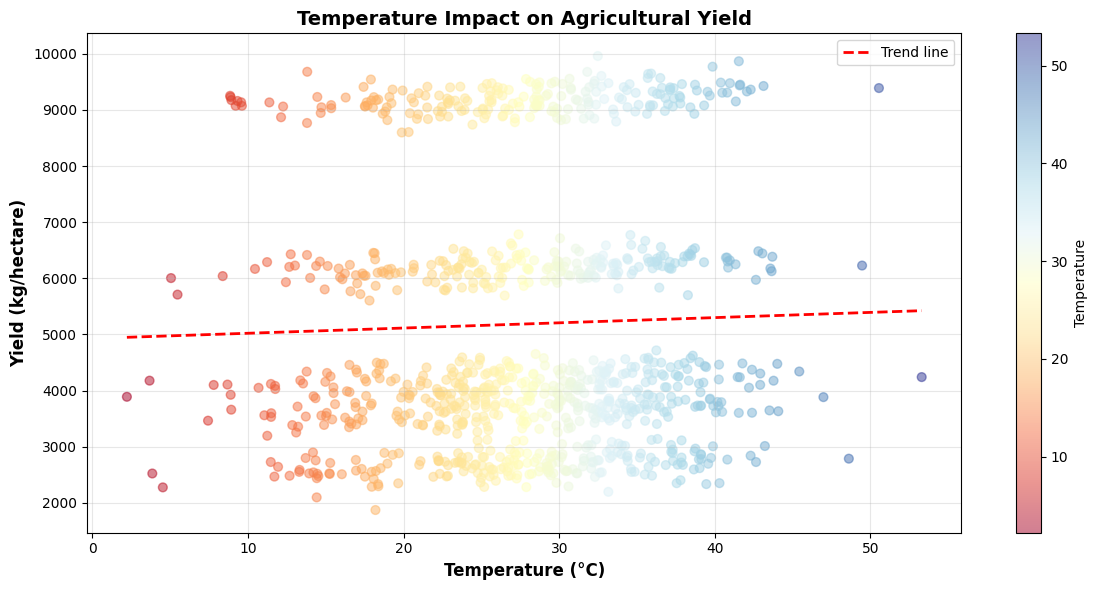

✓ Saved: graph_temp_vs_yield.png


In [3]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(df['Temp'], df['Yield'], alpha=0.5, c=df['Temp'], cmap='RdYlBu', s=40)
z = np.polyfit(df['Temp'], df['Yield'], 1)
p = np.poly1d(z)
ax.plot(sorted(df['Temp']), p(sorted(df['Temp'])), "r--", linewidth=2, label='Trend line')
ax.set_xlabel('Temperature (°C)', fontsize=12, fontweight='bold')
ax.set_ylabel('Yield (kg/hectare)', fontsize=12, fontweight='bold')
ax.set_title('Temperature Impact on Agricultural Yield', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()
plt.colorbar(ax.collections[0], ax=ax, label='Temperature')
plt.tight_layout()
plt.savefig('graph_temp_vs_yield.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: graph_temp_vs_yield.png")

## 3. Distribution Graphs: Rainfall & Yield Histograms

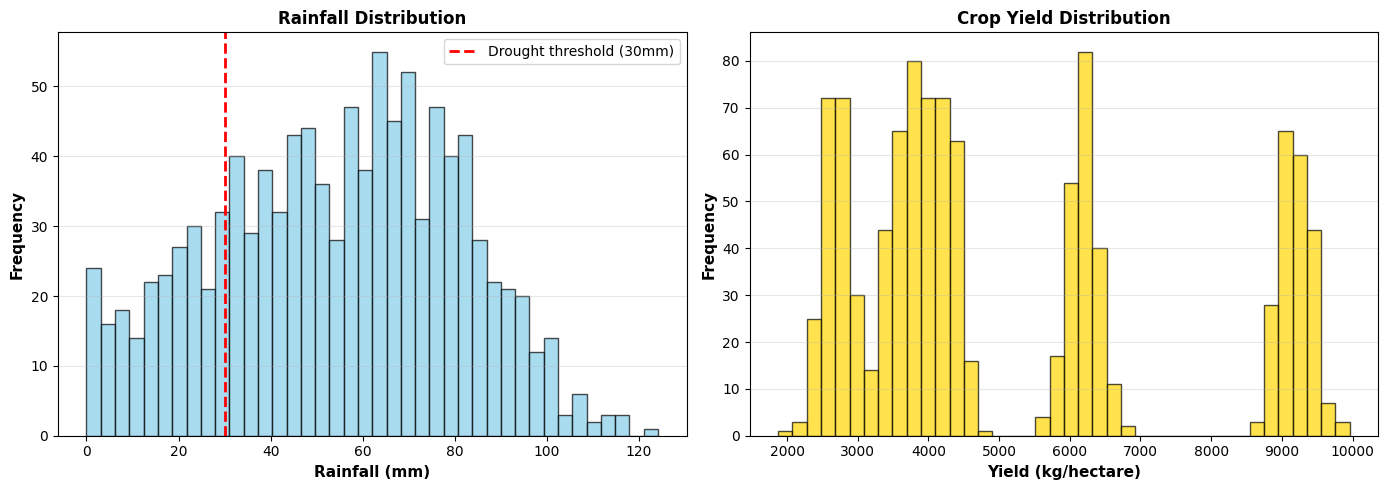

✓ Saved: graph_distributions.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['Rain'], bins=40, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].axvline(30, color='red', linestyle='--', linewidth=2, label='Drought threshold (30mm)')
axes[0].set_xlabel('Rainfall (mm)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[0].set_title('Rainfall Distribution', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')
axes[1].hist(df['Yield'], bins=40, color='gold', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Yield (kg/hectare)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[1].set_title('Crop Yield Distribution', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('graph_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: graph_distributions.png")

## 4. Boxplot Analysis: Price Distribution

C:\Users\Acer\AppData\Local\Temp\ipykernel_24832\3901897930.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(crop_data, labels=crops, patch_artist=True)


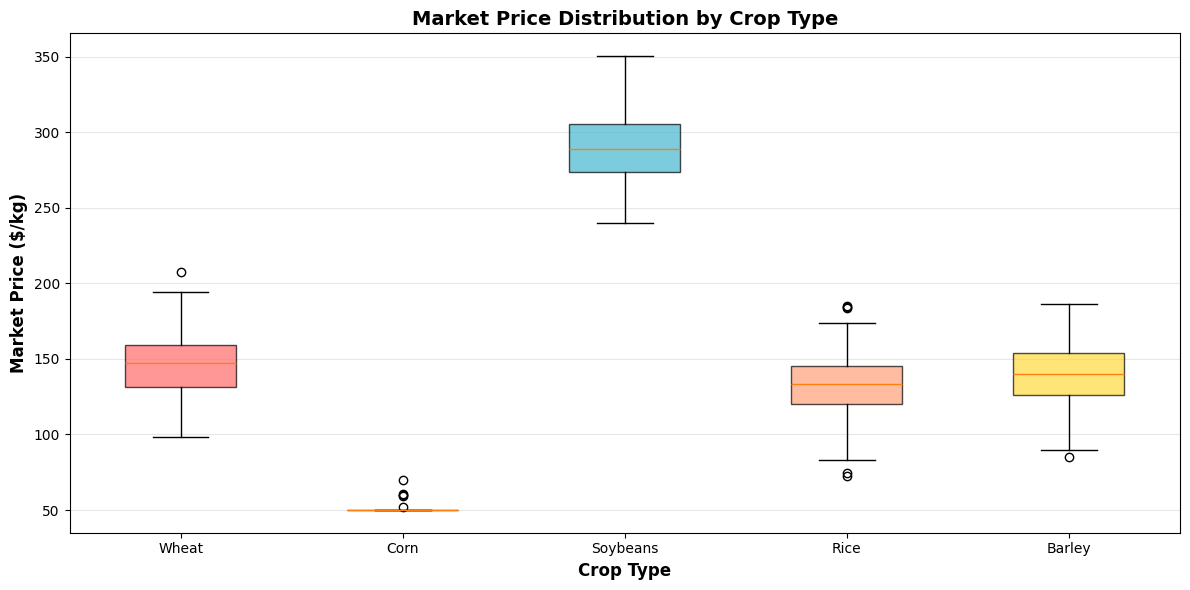

✓ Saved: graph_price_boxplot.png


In [5]:
fig, ax = plt.subplots(figsize=(12, 6))
crop_data = [df[df['Crop'] == crop]['Price'].values for crop in crops]
bp = ax.boxplot(crop_data, labels=crops, patch_artist=True)
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#FFD93D']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('Market Price ($/kg)', fontsize=12, fontweight='bold')
ax.set_xlabel('Crop Type', fontsize=12, fontweight='bold')
ax.set_title('Market Price Distribution by Crop Type', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('graph_price_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: graph_price_boxplot.png")

## 5. Crop Performance Comparison

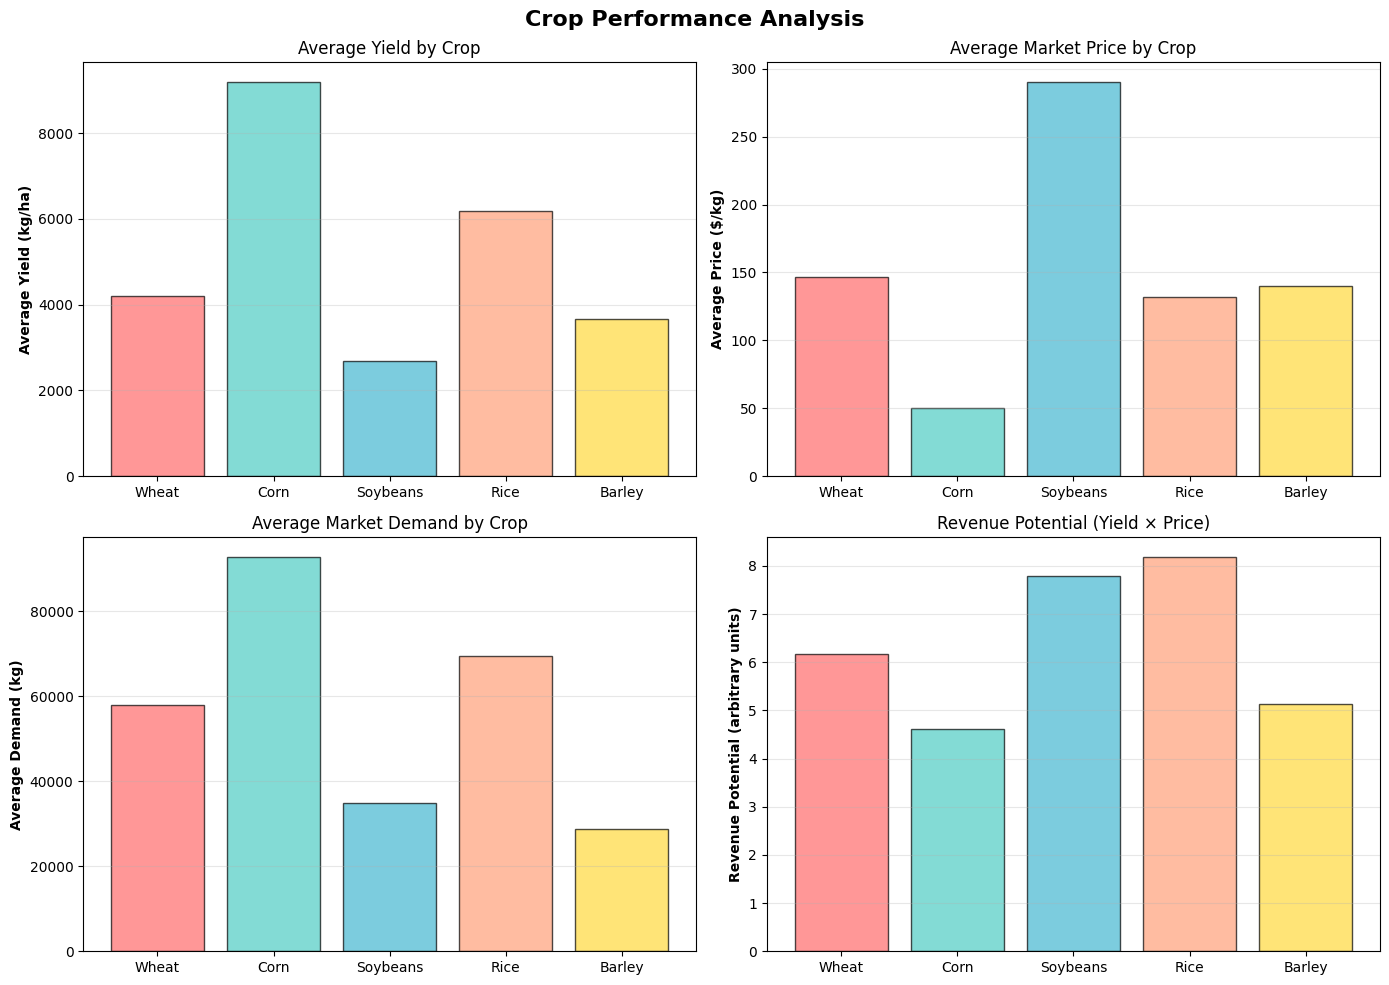

✓ Saved: graph_crop_comparison.png


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Crop Performance Analysis', fontsize=16, fontweight='bold')
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#FFD93D']
crop_yields = {crop: df[df['Crop'] == crop]['Yield'].mean() for crop in crops}
crop_prices = {crop: df[df['Crop'] == crop]['Price'].mean() for crop in crops}
crop_demand = {crop: df[df['Crop'] == crop]['Demand'].mean() for crop in crops}
axes[0, 0].bar(crop_yields.keys(), crop_yields.values(), color=colors, alpha=0.7, edgecolor='black')
axes[0, 0].set_ylabel('Average Yield (kg/ha)', fontweight='bold')
axes[0, 0].set_title('Average Yield by Crop')
axes[0, 0].grid(True, alpha=0.3, axis='y')
axes[0, 1].bar(crop_prices.keys(), crop_prices.values(), color=colors, alpha=0.7, edgecolor='black')
axes[0, 1].set_ylabel('Average Price ($/kg)', fontweight='bold')
axes[0, 1].set_title('Average Market Price by Crop')
axes[0, 1].grid(True, alpha=0.3, axis='y')
axes[1, 0].bar(crop_demand.keys(), crop_demand.values(), color=colors, alpha=0.7, edgecolor='black')
axes[1, 0].set_ylabel('Average Demand (kg)', fontweight='bold')
axes[1, 0].set_title('Average Market Demand by Crop')
axes[1, 0].grid(True, alpha=0.3, axis='y')
revenues = {crop: crop_yields[crop] * crop_prices[crop] / 100000 for crop in crops}
axes[1, 1].bar(revenues.keys(), revenues.values(), color=colors, alpha=0.7, edgecolor='black')
axes[1, 1].set_ylabel('Revenue Potential (arbitrary units)', fontweight='bold')
axes[1, 1].set_title('Revenue Potential (Yield × Price)')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('graph_crop_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: graph_crop_comparison.png")

## 6. Yield-Price Inverse Relationship

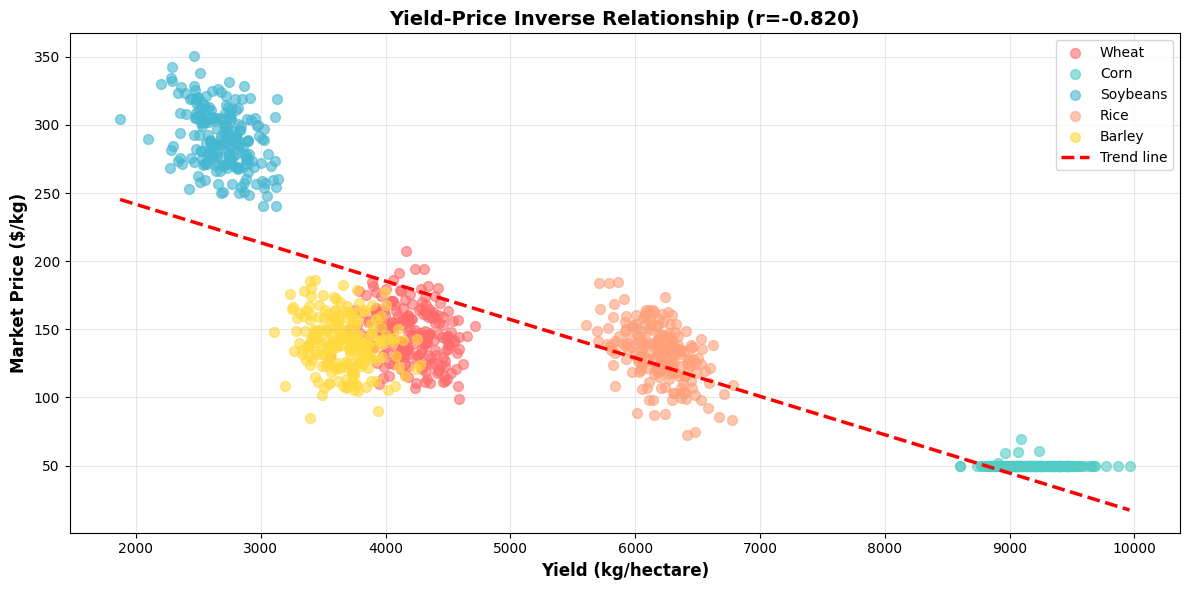

✓ Saved: graph_yield_price.png (Correlation: -0.820)


In [7]:
fig, ax = plt.subplots(figsize=(12, 6))
for i, crop in enumerate(crops):
    mask = df['Crop'] == crop
    ax.scatter(df[mask]['Yield'], df[mask]['Price'], 
              label=crop, alpha=0.6, s=50, c=colors[i])
z = np.polyfit(df['Yield'], df['Price'], 1)
p = np.poly1d(z)
ax.plot(sorted(df['Yield']), p(sorted(df['Yield'])), 
        "r--", linewidth=2.5, label='Trend line', zorder=5)
correlation = np.corrcoef(df['Yield'], df['Price'])[0, 1]

ax.set_xlabel('Yield (kg/hectare)', fontsize=12, fontweight='bold')
ax.set_ylabel('Market Price ($/kg)', fontsize=12, fontweight='bold')
ax.set_title(f'Yield-Price Inverse Relationship (r={correlation:.3f})', 
            fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('graph_yield_price.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved: graph_yield_price.png (Correlation: {correlation:.3f})")

## 7. Time Series: Market Demand & Pricing Trends

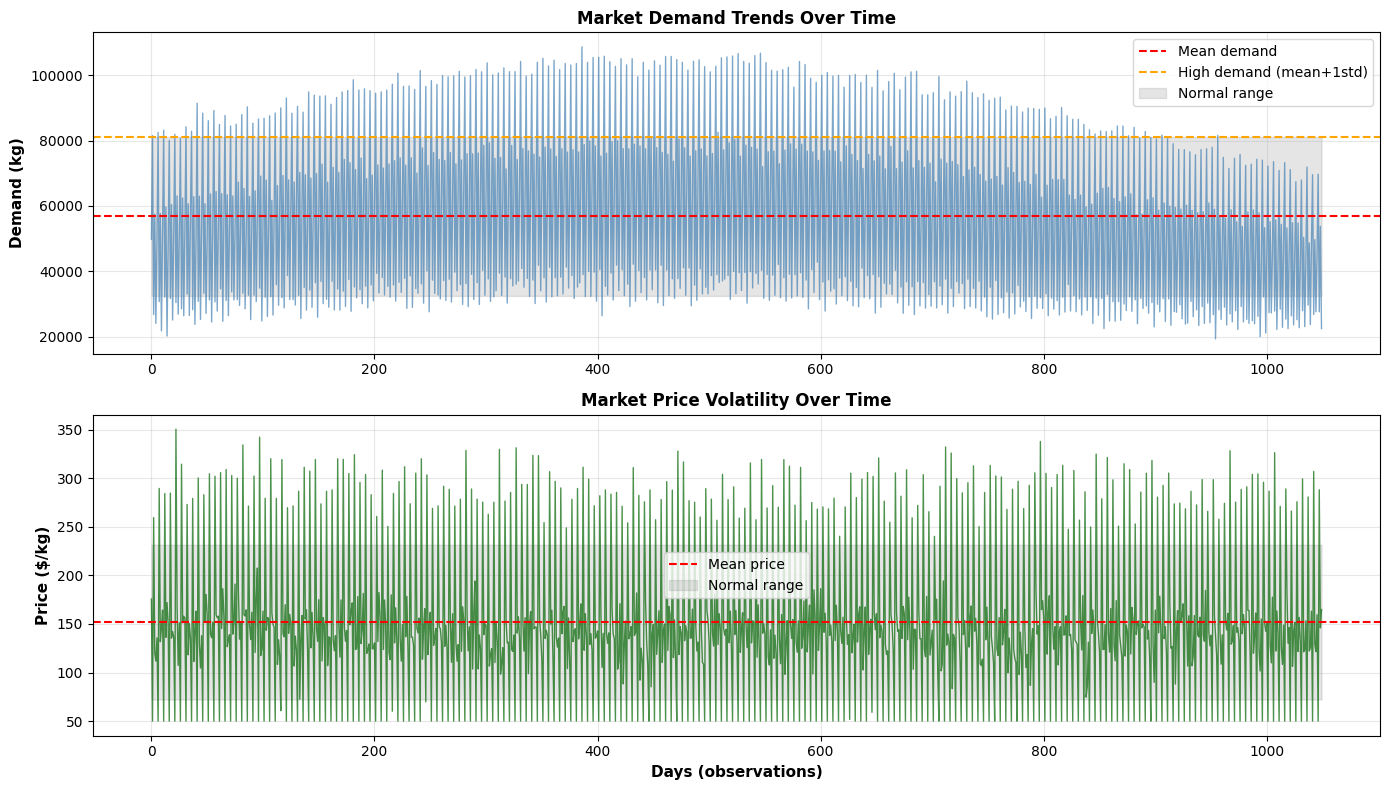

✓ Saved: graph_timeseries.png


In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
axes[0].plot(df['Demand'], linewidth=1, alpha=0.7, color='steelblue')
mean_demand = df['Demand'].mean()
std_demand = df['Demand'].std()
axes[0].axhline(mean_demand, color='r', linestyle='--', label='Mean demand')
axes[0].axhline(mean_demand + std_demand, color='orange', linestyle='--', label='High demand (mean+1std)')
axes[0].fill_between(range(len(df)), mean_demand - std_demand, mean_demand + std_demand, 
                      alpha=0.2, color='gray', label='Normal range')
axes[0].set_ylabel('Demand (kg)', fontsize=11, fontweight='bold')
axes[0].set_title('Market Demand Trends Over Time', fontsize=12, fontweight='bold')
axes[0].legend(loc='best')
axes[0].grid(True, alpha=0.3)
axes[1].plot(df['Price'], linewidth=1, alpha=0.7, color='darkgreen')
mean_price = df['Price'].mean()
std_price = df['Price'].std()
axes[1].axhline(mean_price, color='r', linestyle='--', label='Mean price')
axes[1].fill_between(range(len(df)), mean_price - std_price, mean_price + std_price, 
                      alpha=0.2, color='gray', label='Normal range')
axes[1].set_xlabel('Days (observations)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Price ($/kg)', fontsize=11, fontweight='bold')
axes[1].set_title('Market Price Volatility Over Time', fontsize=12, fontweight='bold')
axes[1].legend(loc='best')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('graph_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: graph_timeseries.png")

## 8. Correlation Heatmap

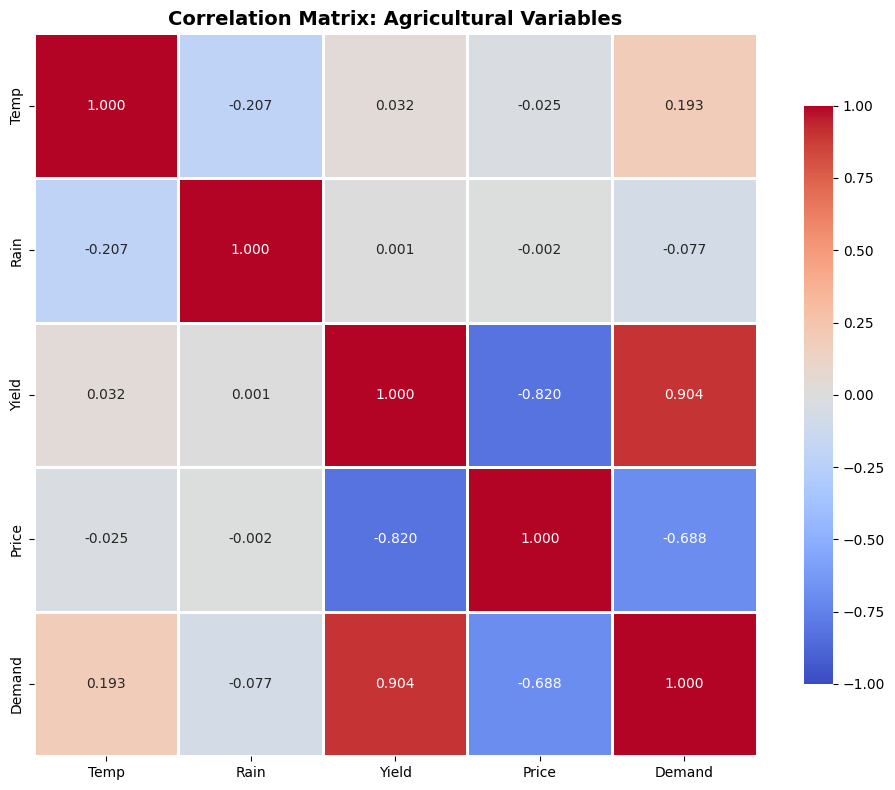

✓ Saved: graph_correlation.png


In [9]:
fig, ax = plt.subplots(figsize=(10, 8))
numeric_cols = ['Temp', 'Rain', 'Yield', 'Price', 'Demand']
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1, ax=ax)

ax.set_title('Correlation Matrix: Agricultural Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('graph_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: graph_correlation.png")

## 9. Summary & Export Report

In [10]:
print("="*70)
print("AGRICULTURAL CLIMATE & MARKET ANALYSIS - GRAPH GENERATION COMPLETE")
print("="*70)

print("\n📊 GRAPHS GENERATED:")
graphs = [
    "graph_temp_vs_yield.png - Temperature impact on yield with trend line",
    "graph_distributions.png - Rainfall & yield distribution histograms",
    "graph_price_boxplot.png - Market price boxplot by crop type",
    "graph_crop_comparison.png - 4-panel crop performance comparison",
    "graph_yield_price.png - Inverse yield-price relationship",
    "graph_timeseries.png - Demand & price trends over time",
    "graph_correlation.png - Correlation heatmap of all variables"
]

for i, graph in enumerate(graphs, 1):
    print(f"{i}. {graph}")

print("\n📈 KEY INSIGHTS:")
print(f"  • Dataset: {len(df)} observations")
print(f"  • Crops: {df['Crop'].nunique()}")
print(f"  • Yield-Price correlation: {np.corrcoef(df['Yield'], df['Price'])[0, 1]:.3f} (inverse)")
print(f"  • Temperature-Yield correlation: {np.corrcoef(df['Temp'], df['Yield'])[0, 1]:.3f}")
print(f"  • Rainfall range: {df['Rain'].min():.1f} - {df['Rain'].max():.1f} mm")
print(f"  • Drought risk events: {sum(df['Rain'] < 30)} (rainfall < 30mm)")
print(f"  • High demand spikes: {sum(df['Demand'] > df['Demand'].mean() + df['Demand'].std())}")

print("\n✅ All graphs saved to project directory!")
print("="*70)

AGRICULTURAL CLIMATE & MARKET ANALYSIS - GRAPH GENERATION COMPLETE

📊 GRAPHS GENERATED:
1. graph_temp_vs_yield.png - Temperature impact on yield with trend line
2. graph_distributions.png - Rainfall & yield distribution histograms
3. graph_price_boxplot.png - Market price boxplot by crop type
4. graph_crop_comparison.png - 4-panel crop performance comparison
5. graph_yield_price.png - Inverse yield-price relationship
6. graph_timeseries.png - Demand & price trends over time
7. graph_correlation.png - Correlation heatmap of all variables

📈 KEY INSIGHTS:
  • Dataset: 1050 observations
  • Crops: 5
  • Yield-Price correlation: -0.820 (inverse)
  • Temperature-Yield correlation: 0.032
  • Rainfall range: 0.0 - 124.1 mm
  • Drought risk events: 216 (rainfall < 30mm)
  • High demand spikes: 181

✅ All graphs saved to project directory!
